# Run the pipeline by looping over lists of motls 

In [7]:
import os
from pathlib import Path
from dna_linker import dna_linkers as dnal
from dna_linker import run_pipeline as run
from dna_linker import config
from cryocat import cryomotl
import numpy as np
import pandas as pd

# Functions

In [8]:
##

In [9]:
def connectivity_to_edge_set(conn_dict):
    """
    Converts a connectivity dictionary of the form
      {node: [(neighbor, prob, type), ...], ...}
    into a set of undirected edges (node1, node2, type) with node1 < node2.
    """
    edges = set()
    for node, neighbors in conn_dict.items():
        for neighbor, _, edge_type in neighbors:
            i, j = sorted((node, neighbor))
            edges.add((i, j, edge_type))
    return edges


def compute_f1_from_connectivity(truth_conn, pred_conn):
    """
    Computes precision, recall, and F1-score between ground-truth
    and predicted connectivity dictionaries.

    Parameters:
        truth_conn (dict): Ground truth connectivity:
            {node: [(neighbor, prob, type), ...], ...}
        pred_conn (dict): Predicted connectivity, same format.

    Returns:
        precision (float), recall (float), f1_score (float)
    """
    # Convert both to undirected edge-sets
    truth_edges = connectivity_to_edge_set(truth_conn)
    pred_edges = connectivity_to_edge_set(pred_conn)

    # True Positives, False Positives, False Negatives
    tp = len(truth_edges & pred_edges)
    fp = len(pred_edges - truth_edges)
    fn = len(truth_edges - pred_edges)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


In [10]:
def add_noise_to_motl(
    motl: cryomotl.Motl,
    pos_sigma: float,
    ang_sigma_deg: float,
    output_filename:str,
    seed: int = None
) -> cryomotl.Motl:
    """
    Returns a copy of `motl` where each particle has independent Gaussian
    noise added to (x,y,z) and (phi,psi,theta).

    Parameters:
        motl: a cryomotl.Motl instance.
        pos_sigma: standard deviation for positional noise (same units as x,y,z).
        ang_sigma_deg: standard deviation for angular noise (degrees).
        seed: optional random seed.

    Returns:
        new_motl: a fresh cryomotl.Motl with motl.df modified.
    """
    df = motl.df.copy()
    rng = np.random.default_rng(seed)

    # add to x,y,z shifts
    for coord in ("x", "y", "z"):
        df[coord] = df[coord] + rng.normal(0, pos_sigma, size=len(df))
    # add to Euler angles
    for ang in ("phi", "psi", "theta"):
        df[ang] = df[ang] + rng.normal(0, ang_sigma_deg, size=len(df))

    # create a new EmMotl object from this DF
    new = cryomotl.Motl(motl_df=df)
    new.write_out(output_filename)
    return new, output_filename


In [11]:
# Fixed inputs
path_mask = './inputs_noisy/'
#path_mask = './inputs/'
entry = 'Threshold_ref_entrymask_r2_resamp_righthand.mrc'
exit = 'Threshold_ref_exitmask_r2_resamp_righthand.mrc'
origin_entry = 'Threshold_ref_Origin_entrymask_r2_resamp_righthand.mrc'
origin_exit = 'Threshold_ref_Origin_exitmask_r2_resamp_righthand.mrc'

# Global config
tracing_distance=config.tracing_distance # Extenrnal user parameter - Distance
pixel_size = config.pixel_size # Models are at in the right scale
bin=config.bin
max_distance=tracing_distance/(pixel_size*bin)



## Create noisy data

# Run all

In [12]:
# EMDs and noise suffixes to test
#emd_list = [2601, 13356, 13363, 13370, 13379, 38407]
emd_list = [2601] #, 13356, 13363, 13370, 13379, 38407]
noise_suffixes = ['noisePos_0_noiseAng_10']#['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes
#noise_suffixes = ['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes

for emd in emd_list:
    for suffix in noise_suffixes:
        print(f"\n>>> Running EMD{emd} with suffix '{suffix}'")

        # Paths
        motl_name = f'motl_EMD{emd}_{suffix}.em'
        name_traced = f'EMD{emd}_tr{int(tracing_distance)}nm_{suffix}.em'
        path_output = f'./out_tracing/EMD{emd}_{suffix}/'
        motl_trace_input = path_output + name_traced

        output_path_cluster = f'./outputs/outputs_EMD{emd}_{suffix}/clusters_20nm/'
        output_path_linker = f'./outputs/outputs_EMD{emd}_{suffix}/A_linkers_20nm/'
        output_path_dictionary = f'./outputs/outputs_EMD{emd}_{suffix}/A_Connections_dictionary_20nm/'

        # Create all output folders if needed
        for path in [
            path_output, output_path_cluster, output_path_linker, output_path_dictionary
        ]:
            Path(path).mkdir(parents=True, exist_ok=True)

        # Run the full pipeline
        run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
        )



>>> Running EMD2601 with suffix 'noisePos_0_noiseAng_10'
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_10/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11}
Size of largest connected component: 11
{0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11}
Figure(640x480)


In [13]:
import pandas as pd

# Load your ground truth and prediction dicts
gt = pd.read_pickle('./outputs/outputs_EMD2601_STA_tmpl/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')
pred = pd.read_pickle('./outputs/outputs_EMD2601_noisePos_0_noiseAng_10/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')

prec, rec, f1 = compute_f1_from_connectivity(gt, pred)
print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")


Precision: 1.000, Recall: 1.000, F1: 1.000


In [14]:
pos_sigmas=np.arange(0,31, 5)
pos_sigmas

array([ 0,  5, 10, 15, 20, 25, 30])

# Loop over noise in position

In [35]:
%%time

pos_sigmas=np.array([0,1,3,5,10,15,20,25,30])


f1_lists=[]
prec_lists=[]
rec_lists=[]
for pos_sigma in pos_sigmas[1:]:
    f1_list=[]
    prec_list=[]
    rec_list=[]
    for i in range(0, 50):
        #pos_sigma = 10 # AA
        ang_sigma_deg = 0 # deg
        
        new=add_noise_to_motl(
            motl= cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em') ,
            pos_sigma=pos_sigma,
            ang_sigma_deg=ang_sigma_deg,
            output_filename=f'inputs_noisy/motl_EMD2601_noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}.em'
        )
        
        
        # EMDs and noise suffixes to test
        #emd_list = [2601, 13356, 13363, 13370, 13379, 38407]
        emd_list = [2601] #, 13356, 13363, 13370, 13379, 38407]
        noise_suffixes = [f'noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}']#['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes
        #noise_suffixes = ['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes
        
        for emd in emd_list:
            for suffix in noise_suffixes:
                print(f"\n>>> Running EMD{emd} with suffix '{suffix}'")
        
                # Paths
                motl_name = f'motl_EMD{emd}_{suffix}.em'
                name_traced = f'EMD{emd}_tr{int(tracing_distance)}nm_{suffix}.em'
                path_output = f'./out_tracing/EMD{emd}_{suffix}/'
                motl_trace_input = path_output + name_traced
        
                output_path_cluster = f'./outputs/outputs_EMD{emd}_{suffix}/clusters_20nm/'
                output_path_linker = f'./outputs/outputs_EMD{emd}_{suffix}/A_linkers_20nm/'
                output_path_dictionary = f'./outputs/outputs_EMD{emd}_{suffix}/A_Connections_dictionary_20nm/'
        
                # Create all output folders if needed
                for path in [
                    path_output, output_path_cluster, output_path_linker, output_path_dictionary
                ]:
                    Path(path).mkdir(parents=True, exist_ok=True)
        
                # Run the full pipeline
                run.run_full_pipeline(
                    path_mask=path_mask,
                    motl_name=motl_name,
                    entry=entry,
                    exit=exit,
                    origin_entry=origin_entry,
                    origin_exit=origin_exit,
                    path_output=path_output,
                    motl_trace_input=motl_trace_input,
                    tracing_distance=tracing_distance,
                    max_distance=max_distance,
                    output_path_cluster=output_path_cluster,
                    output_path_linker=output_path_linker,
                    output_path_dictionary=output_path_dictionary,
                    dnal_object=dnal.lo,
                    max_processes=8
                )
    
        gt = pd.read_pickle('./outputs/outputs_EMD2601_STA_tmpl/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')
        pred = pd.read_pickle(f'./outputs/outputs_EMD2601_noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')
    
        prec, rec, f1 = compute_f1_from_connectivity(gt, pred)
        print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
        f1_list.append(f1)
        prec_list.append(prec)
        rec_list.append(rec)
    
    f1_lists.append(f1_list)
    prec_lists.append(prec_list)
    rec_lists.append(rec_list)



>>> Running EMD2601 with suffix 'noisePos_1_noiseAng_0'
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)
Precision: 0.750, Recall: 0.750, F1: 0.750

>>> Running EMD2601 with suffix 'noisePos_1_noiseAng_0'
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 4, 5, 6, 8, 10, 11}
Size of largest connected component: 8
{0, 2, 4, 5, 6, 8, 10, 11}
Figure(640x480)
Precision: 0.583, Recall: 0.583, F1: 0.583

>>> Running EMD2601 with suffix 'noisePos_1_noiseAng_0'
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm

## version 2

In [15]:
%%time
from pathlib import Path
from tqdm.auto import tqdm

# -------------------------------------------
# 1.  EXPERIMENT SETTINGS
# -------------------------------------------
N_TRIALS      = 2# 50
POS_SIGMAS    = np.array([1, 3, 5, 10, 15, 20, 25, 30])   # 0 Å left out on purpose
ANG_SIGMA_DEG = 0
EMD_ID        = 2601                                      # only one map for now

# -------------------------------------------
# 2.  STATIC FILES & CONSTANTS
# -------------------------------------------
GT_PATH = (
    './outputs/outputs_EMD2601_STA_tmpl/'
    'A_Connections_dictionary_20nm/'
    'Connectivity_motl_tomo0.0_cluster12.0.pickle'
)
GT_DICT = pd.read_pickle(GT_PATH)                         # read **once**

# where to collect numbers ↓
records = []

# -------------------------------------------
# 3.  SWEEP OVER NOISE LEVELS
# -------------------------------------------
for pos_sigma in tqdm(POS_SIGMAS, desc='σ translational noise (Å)'):
    # fresh containers for this σ if you still need them later
    f1_list, prec_list, rec_list = [], [], []

    for trial in tqdm(range(N_TRIALS),
                      desc=f'{pos_sigma:>2} Å trials',
                      leave=False):
        # 3-a) Generate a noisy motive-list -----------------------------
        suffix = f'noisePos_{pos_sigma}_noiseAng_{ANG_SIGMA_DEG}'
        add_noise_to_motl(
            motl=cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em'),
            pos_sigma=pos_sigma,
            ang_sigma_deg=ANG_SIGMA_DEG,
            output_filename=f'inputs_noisy/motl_EMD{EMD_ID}_{suffix}.em'
        )

        # 3-b) Build paths ---------------------------------------------
        motl_name = f'motl_EMD{EMD_ID}_{suffix}.em'
        path_output = f'./out_tracing/EMD{EMD_ID}_{suffix}/'
        motl_trace_input = path_output + f'EMD{EMD_ID}_tr{int(tracing_distance)}nm_{suffix}.em'

        output_path_cluster     = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/clusters_20nm/'
        output_path_linker      = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_linkers_20nm/'
        output_path_dictionary  = f'./outputs/outputs_EMD{EMD_ID}_{suffix}/A_Connections_dictionary_20nm/'

        for p in [path_output, output_path_cluster,
                  output_path_linker, output_path_dictionary]:
            Path(p).mkdir(parents=True, exist_ok=True)

        # 3-c) Run the pipeline ----------------------------------------
        run.run_full_pipeline(
            path_mask=path_mask,
            motl_name=motl_name,
            entry=entry,
            exit=exit,
            origin_entry=origin_entry,
            origin_exit=origin_exit,
            path_output=path_output,
            motl_trace_input=motl_trace_input,
            tracing_distance=tracing_distance,
            max_distance=max_distance,
            output_path_cluster=output_path_cluster,
            output_path_linker=output_path_linker,
            output_path_dictionary=output_path_dictionary,
            dnal_object=dnal.lo,
            max_processes=8
        )

        # 3-d) Metrics -------------------------------------------------
        pred_path = (
            f'./outputs/outputs_EMD{EMD_ID}_{suffix}/'
            'A_Connections_dictionary_20nm/'
            'Connectivity_motl_tomo0.0_cluster12.0.pickle'
        )
        pred_dict = pd.read_pickle(pred_path)

        prec, rec, f1 = compute_f1_from_connectivity(GT_DICT, pred_dict)

        # keep per-σ lists (optional)
        f1_list  .append(f1)
        prec_list.append(prec)
        rec_list .append(rec)

        # flat record for DataFrame
        records.append({
            'sigma': pos_sigma,
            'trial': trial,
            'precision': prec,
            'recall'   : rec,
            'f1'       : f1
        })

    # END inner loop over trials
# END outer loop over σ

# -------------------------------------------
# 4.  SAVE EVERYTHING TO DISK
# -------------------------------------------
df = pd.DataFrame(records)
df.to_pickle('noise_sweep_metrics.pkl')       # **full fidelity**
df.to_csv   ('noise_sweep_metrics.csv', index=False)

# save also as NumPy arrays (shape: [σ, trials])
pivot = (
    df.pivot(index='sigma', columns='trial', values=['precision', 'recall', 'f1'])
      .sort_index()
      .to_numpy()
)
np.savez(
    'noise_sweep_metrics.npz',
    pos_sigmas = POS_SIGMAS,
    precision  = pivot[0],   # precision matrix
    recall     = pivot[1],   # recall    "
    f1         = pivot[2]    # f1        "
)

print(' Results written to noise_sweep_metrics.(pkl | csv | npz)')


σ translational noise (Å):   0%|          | 0/8 [00:00<?, ?it/s]

 1 Å trials:   0%|          | 0/2 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Size of largest connected component: 12
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_1_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)


 3 Å trials:   0%|          | 0/2 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_3_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 4, 5, 6, 8, 10, 11}
Size of largest connected component: 8
{0, 1, 4, 5, 6, 8, 10, 11}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_3_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Size of largest connected component: 10
{0, 1, 2, 4, 5, 6, 8, 9, 10, 11}
Figure(640x480)


...

The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {8, 1, 4}
Size of largest connected component: 3
{8, 1, 4}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_20_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 7, 8, 10, 11}
Size of largest connected component: 7
{0, 2, 3, 7, 8, 10, 11}
Figure(640x480)


25 Å trials:   0%|          | 0/2 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {2, 3, 5, 7, 8, 10}
Size of largest connected component: 6
{2, 3, 5, 7, 8, 10}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster11.0.em has been saved!
The file:  ./outputs/outputs_EMD2601_noisePos_25_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster1.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 11.0
Figure(640x480)
(11, 11, 4)
Largest connected component: {0, 9, 3, 6}
Size of largest connected component: 4
{0, 9, 3, 6}
Figure(640x480)
Tomogram: 0.0, and cluster 1.0
Figure(640x480)
(1, 1, 4)
0
Figure(640x480)


30 Å trials:   0%|          | 0/2 [00:00<?, ?it/s]

The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {9, 3, 5, 6}
Size of largest connected component: 4
{9, 3, 5, 6}
Figure(640x480)
The file:  ./outputs/outputs_EMD2601_noisePos_30_noiseAng_0/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 10, 11}
Size of largest connected component: 3
{0, 10, 11}
Figure(640x480)
 Results written to noise_sweep_metrics.(pkl | csv | npz)
CPU times: user 15.5 s, sys: 2.86 s, total: 18.4 s
Wall time: 1min 25s


In [37]:
np.mean(np.array(f1_lists), axis=-1), np.std(np.array(f1_lists), axis=-1) 

(array([0.71566667, 0.72890909, 0.71957576, 0.65558297, 0.56694299,
        0.48876861, 0.46794642, 0.38405844]),
 array([0.14057066, 0.16943617, 0.16088308, 0.1750031 , 0.18056525,
        0.16816868, 0.1673671 , 0.17610036]))

In [38]:
np.shape(f1_lists)

(8, 50)

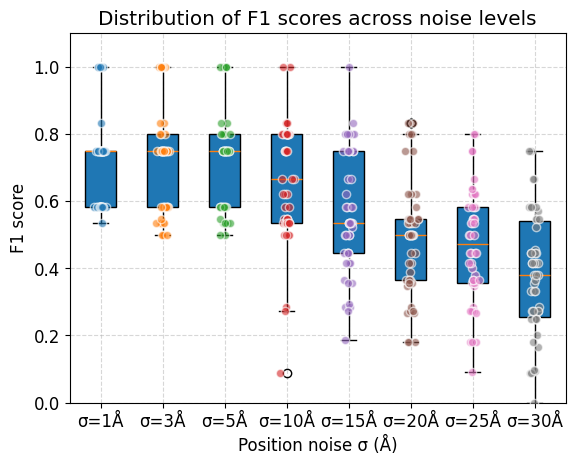

In [39]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(f1_lists)


sigmas = [ 1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
#plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}Å' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Position noise σ (Å)')
plt.ylabel('F1 score')
plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


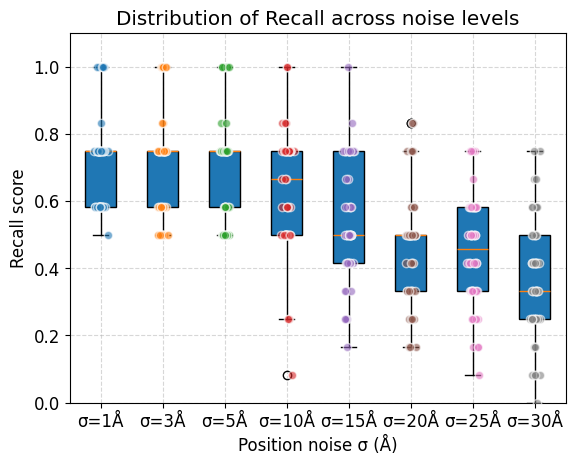

In [40]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(rec_lists)


sigmas_ = [ 1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}Å' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Position noise σ (Å)')
plt.ylabel('Recall score')
plt.title('Distribution of Recall across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


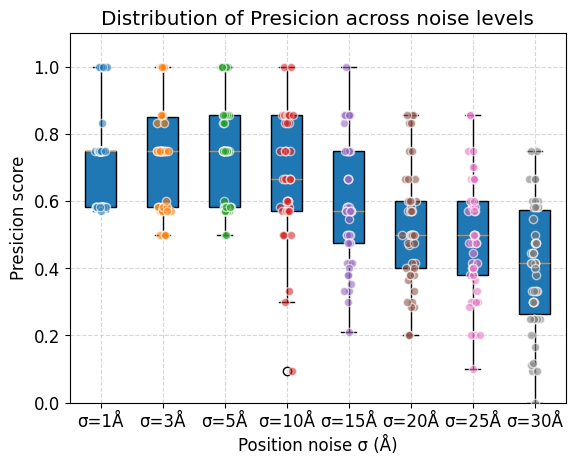

In [42]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(prec_lists)


sigmas = [ 1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}Å' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Position noise σ (Å)')
plt.ylabel('Presicion score')
plt.title('Distribution of Presicion across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


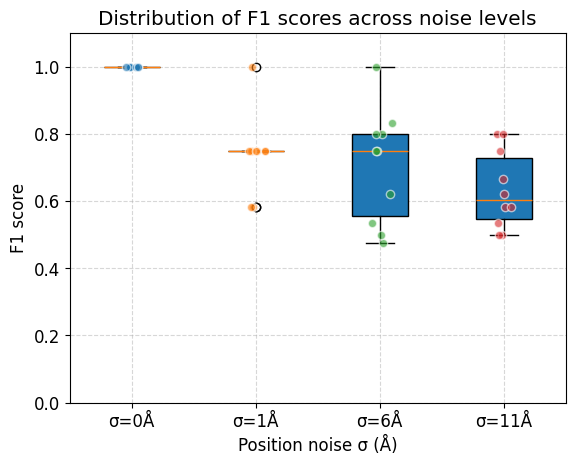

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Data arrays for different position noise sigma values
data_sigma0 = [1.0] * 10  # perfect F1 at zero noise
data_sigma1 = [0.75, 0.75, 0.5833333333333334, 0.75, 0.75, 0.75, 0.5833333333333334, 0.75, 1.0, 0.75]
data_sigma6 = [0.75, 0.7999999999999999, 0.75, 0.5333333333333333, 0.7999999999999999, 0.4761904761904762, 0.6222222222222222, 0.8333333333333334, 0.5, 1.0]
data_sigma11 = [0.6666666666666666, 0.5833333333333334, 0.75, 0.7999999999999999, 0.5833333333333334, 0.6222222222222222, 0.7999999999999999, 0.5, 0.5, 0.5333333333333333]

# Combine data and labels
data = [data_sigma0, data_sigma1, data_sigma6, data_sigma11]
sigmas = [ 0,  5, 10, 15, 20, 25, 30]

# Create the figure
plt.figure()

# Boxplot
plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)

# Overlay individual data points with jitter
for i, ys in enumerate(data, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Position noise σ (Å)')
plt.ylabel('F1 score')
plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


In [ ]:
f1_lists

## ANGLES

In [43]:
%%time

ang_sigmas=np.array([0,1,3,5,10,15,20,25,30])


f1_lists_angles=[]
prec_lists_angles=[]
rec_lists_angles=[]
for ang_sigma_deg in ang_sigmas[1:]:
    f1_list_angles=[]
    prec_list_angles=[]
    rec_list_angles=[]
    for i in range(0, 50):
        pos_sigma = 0 # AA
        #ang_sigma_deg = 0 # deg
        
        new=add_noise_to_motl(
            motl= cryomotl.EmMotl('inputs/motl_EMD2601_STA_tmpl.em') ,
            pos_sigma=pos_sigma,
            ang_sigma_deg=ang_sigma_deg,
            output_filename=f'inputs_noisy/motl_EMD2601_noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}.em'
        )
        
        
        # EMDs and noise suffixes to test
        #emd_list = [2601, 13356, 13363, 13370, 13379, 38407]
        emd_list = [2601] #, 13356, 13363, 13370, 13379, 38407]
        noise_suffixes = [f'noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}']#['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes
        #noise_suffixes = ['STA_tmpl']#, 'noise_25', 'noise_angle_1deg']  # file suffixes
        
        for emd in emd_list:
            for suffix in noise_suffixes:
                print(f"\n>>> Running EMD{emd} with suffix '{suffix}'")
        
                # Paths
                motl_name = f'motl_EMD{emd}_{suffix}.em'
                name_traced = f'EMD{emd}_tr{int(tracing_distance)}nm_{suffix}.em'
                path_output = f'./out_tracing/EMD{emd}_{suffix}/'
                motl_trace_input = path_output + name_traced
        
                output_path_cluster = f'./outputs/outputs_EMD{emd}_{suffix}/clusters_20nm/'
                output_path_linker = f'./outputs/outputs_EMD{emd}_{suffix}/A_linkers_20nm/'
                output_path_dictionary = f'./outputs/outputs_EMD{emd}_{suffix}/A_Connections_dictionary_20nm/'
        
                # Create all output folders if needed
                for path in [
                    path_output, output_path_cluster, output_path_linker, output_path_dictionary
                ]:
                    Path(path).mkdir(parents=True, exist_ok=True)
        
                # Run the full pipeline
                run.run_full_pipeline(
                    path_mask=path_mask,
                    motl_name=motl_name,
                    entry=entry,
                    exit=exit,
                    origin_entry=origin_entry,
                    origin_exit=origin_exit,
                    path_output=path_output,
                    motl_trace_input=motl_trace_input,
                    tracing_distance=tracing_distance,
                    max_distance=max_distance,
                    output_path_cluster=output_path_cluster,
                    output_path_linker=output_path_linker,
                    output_path_dictionary=output_path_dictionary,
                    dnal_object=dnal.lo,
                    max_processes=8
                )
    
        gt = pd.read_pickle('./outputs/outputs_EMD2601_STA_tmpl/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')
        pred = pd.read_pickle(f'./outputs/outputs_EMD2601_noisePos_{pos_sigma}_noiseAng_{ang_sigma_deg}/A_Connections_dictionary_20nm/Connectivity_motl_tomo0.0_cluster12.0.pickle')
    
        prec, rec, f1 = compute_f1_from_connectivity(gt, pred)
        print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
        f1_list_angles.append(f1)
        prec_list_angles.append(prec)
        rec_list_angles.append(rec)
    
    f1_lists_angles.append(f1_list_angles)
    prec_lists_angles.append(prec_list_angles)
    rec_lists_angles.append(rec_list_angles)



>>> Running EMD2601 with suffix 'noisePos_0_noiseAng_1'
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Size of largest connected component: 10
{0, 2, 3, 4, 5, 6, 7, 8, 10, 11}
Figure(640x480)
Precision: 0.857, Recall: 0.750, F1: 0.800

>>> Running EMD2601 with suffix 'noisePos_0_noiseAng_1'
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo0.0_cluster12.0.em has been saved!
Tomogram: 0.0
Tomogram: 0.0, and cluster 12.0
Figure(640x480)
(12, 12, 4)
Largest connected component: {1, 3, 4, 5, 6, 7, 8}
Size of largest connected component: 7
{1, 3, 4, 5, 6, 7, 8}
Figure(640x480)
Precision: 0.833, Recall: 0.833, F1: 0.833

>>> Running EMD2601 with suffix 'noisePos_0_noiseAng_1'
The file:  ./outputs/outputs_EMD2601_noisePos_0_noiseAng_1/clusters_20nm/motl_tomo

In [53]:
np.mean(np.array(prec_lists_angles), axis=-1), np.std(np.array(f1_lists_angles), axis=-1) 

(array([0.78357143, 0.76547619, 0.68008635, 0.51752941, 0.40058543,
        0.35454388, 0.29693091, 0.19282782]),
 array([0.14643201, 0.15389084, 0.17920939, 0.22128599, 0.17583001,
        0.15176116, 0.13429303, 0.12864526]))

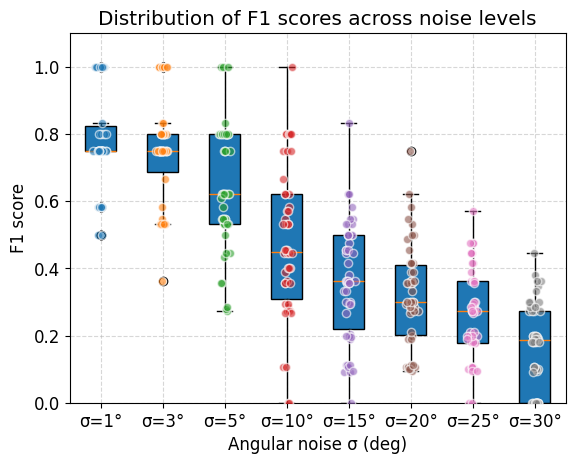

In [49]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(f1_lists_angles)


sigmas = [ 1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
#plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}°' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Angular noise σ (deg)')
plt.ylabel('F1 score')
plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


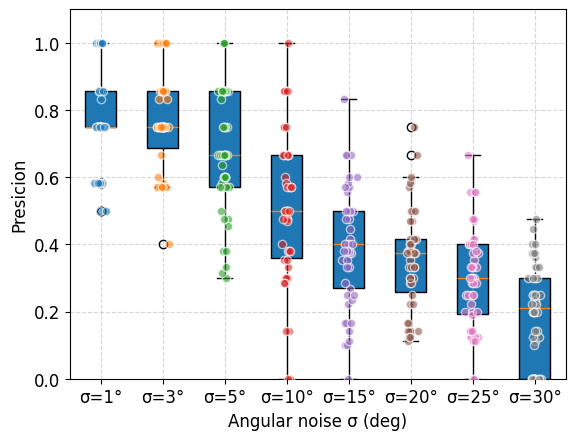

In [58]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(prec_lists_angles)


sigmas = [1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
#plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}°' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Angular noise σ (deg)')
plt.ylabel('Presicion')
#plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


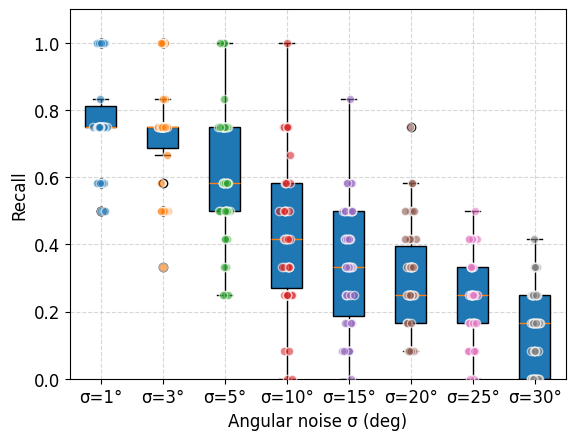

In [57]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(rec_lists_angles)


sigmas = [1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
#plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}°' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Angular noise σ (deg)')
plt.ylabel('Recall')
#plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.array(rec_lists_angles)


sigmas = [1,3,5,10,15,20,25,30]

# Create the figure
plt.figure()

# Boxplot
#plt.boxplot(data, labels=[f'σ={s}Å' for s in sigmas], patch_artist=True)
plt.boxplot(arr.T,  # boxplot expects a sequence of *columns*, so transpose
            labels=[f'σ={s}°' for s in sigmas],
            patch_artist=True,)
             

# Overlay individual data points with jitter
for i, ys in enumerate(arr, start=1):
    x = np.random.normal(i, 0.04, size=len(ys))  # jitter on x-axis
    plt.scatter(x, ys, alpha=0.6, edgecolors='w', zorder=10)

# Labels and title
plt.xlabel('Angular noise σ (deg)')
plt.ylabel('Recall')
#plt.title('Distribution of F1 scores across noise levels')
plt.grid(True, linestyle='--', alpha=0.5)

plt.ylim([0,1.1])
# Show plot
plt.show()


NameError: name 'rec_lists_angles' is not defined